<a href="https://colab.research.google.com/github/amit20kr/Coal_Rock-identification/blob/main/FinalTrainingCR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# SETUP & LOAD
import torch
import torch.nn as nn
import torch.optim as o
import numpy as np
import time
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler, autocast
from tqdm.notebook import tqdm
from sklearn.metrics import classification_report, confusion_matrix

# Config
PROJECT_ROOT = "/content/drive/MyDrive/coalrock_project"
PROCESSED_PATH = f"{PROJECT_ROOT}/processed_data"
MODEL_SAVE_PATH = f"{PROJECT_ROOT}/models/pcvit_expert.pth"
HISTORY_PATH = f"{PROJECT_ROOT}/models/training_history_expert.pkl"
BATCH_SIZE = 32

# Load Data
print(" Loading Processed Tensors...")
X_train = np.load(f"{PROCESSED_PATH}/X_train.npy")
y_train = np.load(f"{PROCESSED_PATH}/y_train.npy")
X_val   = np.load(f"{PROCESSED_PATH}/X_val.npy")
y_val   = np.load(f"{PROCESSED_PATH}/y_val.npy")
X_test  = np.load(f"{PROCESSED_PATH}/X_test.npy")
y_test  = np.load(f"{PROCESSED_PATH}/y_test.npy")

with open(f"{PROCESSED_PATH}/label_encoder.pkl", 'rb') as f:
    le = pickle.load(f)

# Define Dataset
class CoalDataset(Dataset):
    def __init__(self, x, y):
        self.x = torch.from_numpy(x).float()
        self.y = torch.from_numpy(y).long()
    def __len__(self): return len(self.y)
    def __getitem__(self, i): return self.x[i], self.y[i]

# Loaders
train_dl = DataLoader(CoalDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
val_dl   = DataLoader(CoalDataset(X_val, y_val), batch_size=BATCH_SIZE, shuffle=False)
test_dl  = DataLoader(CoalDataset(X_test, y_test), batch_size=BATCH_SIZE, shuffle=False)

print(f" Data Ready. Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

 Loading Processed Tensors...
 Data Ready. Train: 8411 | Val: 2086 | Test: 2086


In [2]:
# MODEL DEFINITION
class PCViT(nn.Module):
    def __init__(self, num_classes=24):
        super().__init__()
        # CNN Stem
        self.stem = nn.Sequential(
            nn.Conv1d(3, 64, 3, 2, 1), nn.BatchNorm1d(64), nn.GELU(),
            nn.Conv1d(64, 128, 1), nn.BatchNorm1d(128), nn.GELU(),
            nn.Conv1d(128, 128, 3, 2, 1), nn.BatchNorm1d(128), nn.GELU()
        )
        # Transformer
        self.cls = nn.Parameter(torch.randn(1, 1, 128))
        self.pos = nn.Parameter(torch.randn(1, 376, 128))
        self.tf = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(128, 4, 512, 0.1, 'gelu', batch_first=True),
            4
        )
        self.head = nn.Sequential(nn.LayerNorm(128), nn.Linear(128, num_classes))

    def forward(self, x):
        x = self.stem(x).permute(0, 2, 1)
        x = torch.cat([self.cls.expand(x.shape[0], -1, -1), x], 1)
        x = x + self.pos[:, :x.shape[1], :]
        return self.head(self.tf(x)[:, 0])

print("PCViT Architecture Defined.")

PCViT Architecture Defined.


In [3]:
# MIXUP FUNCTIONS
def mixup_data(x, y, alpha=1.0):
    '''Returns mixed inputs, pairs of targets, and lambda'''
    if alpha > 0: lam = np.random.beta(alpha, alpha)
    else: lam = 1

    batch_size = x.size(0)
    index = torch.randperm(batch_size).cuda()
    mixed_x = lam * x + (1 - lam) * x[index, :]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

print(" Mixup Logic Ready.")

 Mixup Logic Ready.


In [4]:
# INITIALIZATION
model = PCViT(num_classes=24).cuda()

# Weights Init Function
def init_weights(m):
    if isinstance(m, nn.Linear) or isinstance(m, nn.Conv1d):
        torch.nn.init.xavier_uniform_(m.weight)
        if m.bias is not None: m.bias.data.fill_(0.01)

model.apply(init_weights)

# Optimizer & Scheduler
criterion = nn.CrossEntropyLoss()
opt = o.AdamW(model.parameters(), lr=0.0003, weight_decay=0.05) # Higher decay for robustness
scaler = GradScaler()
scheduler = o.lr_scheduler.ReduceLROnPlateau(opt, mode='max', factor=0.5, patience=3)

print("Model Reset & Initialized.")

Model Reset & Initialized.


/tmp/ipykernel_1831/55602601.py:15: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


In [ ]:
# TRAINING LOOP
import time

# Config
EPOCHS = 35
MIXUP_EPOCHS = 25
MODEL_SAVE_PATH = f"{PROJECT_ROOT}/models/pcvit_expert.pth"
HISTORY_PATH = f"{PROJECT_ROOT}/models/training_history_expert.pkl"

# Init History
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_acc = 0.0

print(f"  Starting 2-Stage Training ({EPOCHS} Epochs)...")
print(f"   Phase 1: Robust Learning (Mixup ON) -> Epoch 1-{MIXUP_EPOCHS}")
print(f"   Phase 2: Fine Tuning (Mixup OFF)    -> Epoch {MIXUP_EPOCHS+1}-{EPOCHS}")

start_time = time.time()

for ep in range(EPOCHS):
    model.train()
    run_loss = 0.0
    train_correct = 0
    train_total = 0

    # Check Phase
    is_mixup_phase = ep < MIXUP_EPOCHS
    desc = f"Ep {ep+1} [Mixup {'ON' if is_mixup_phase else 'OFF'}]"

    pbar = tqdm(train_dl, desc=desc, leave=False)

    for x, y in pbar:
        x, y = x.cuda(), y.cuda()
        opt.zero_grad()

        # APPLY MIXUP ONLY IN PHASE 1
        if is_mixup_phase and np.random.rand() > 0.5:
            inputs, y_a, y_b, lam = mixup_data(x, y, alpha=1.0)
            with autocast():
                out = model(inputs)
                loss = mixup_criterion(criterion, out, y_a, y_b, lam)

            _, predicted = torch.max(out.data, 1)
            train_correct += (lam * (predicted == y_a).float() + (1 - lam) * (predicted == y_b).float()).sum().item()
        else:
            with autocast():
                out = model(x)
                loss = criterion(out, y)
            _, predicted = torch.max(out.data, 1)
            train_correct += (predicted == y).sum().item()

        scaler.scale(loss).backward()
        scaler.step(opt)
        scaler.update()

        run_loss += loss.item()
        train_total += y.size(0)
        pbar.set_postfix({'loss': f"{loss.item():.4f}"})


    model.eval()
    val_correct = 0; val_total = 0; val_loss = 0.0
    with torch.no_grad():
        for x, y in val_dl:
            x, y = x.cuda(), y.cuda()
            out = model(x)
            val_loss += criterion(out, y).item()
            _, pred = torch.max(out.data, 1)
            val_total += y.size(0)
            val_correct += (pred == y).sum().item()

    # METRICS & SCHEDULER
    t_loss = run_loss / len(train_dl)
    t_acc  = 100 * train_correct / train_total
    v_loss = val_loss / len(val_dl)
    v_acc  = 100 * val_correct / val_total

    history['train_loss'].append(t_loss)
    history['val_loss'].append(v_loss)
    history['train_acc'].append(t_acc)
    history['val_acc'].append(v_acc)

    if not is_mixup_phase:
        scheduler.step(v_acc)

    print(f"{desc}: Train Acc {t_acc:.2f}% | Val Acc {v_acc:.2f}% | Gap: {v_acc-t_acc:.1f}%")

    if v_acc > best_acc:
        best_acc = v_acc
        torch.save(model.state_dict(), MODEL_SAVE_PATH)
        print(f"   Best Model Saved ({best_acc:.2f}%)")

with open(HISTORY_PATH, 'wb') as f: pickle.dump(history, f)
print(f"Training Complete. Best Accuracy: {best_acc:.2f}%")

In [ ]:
import pandas as pd

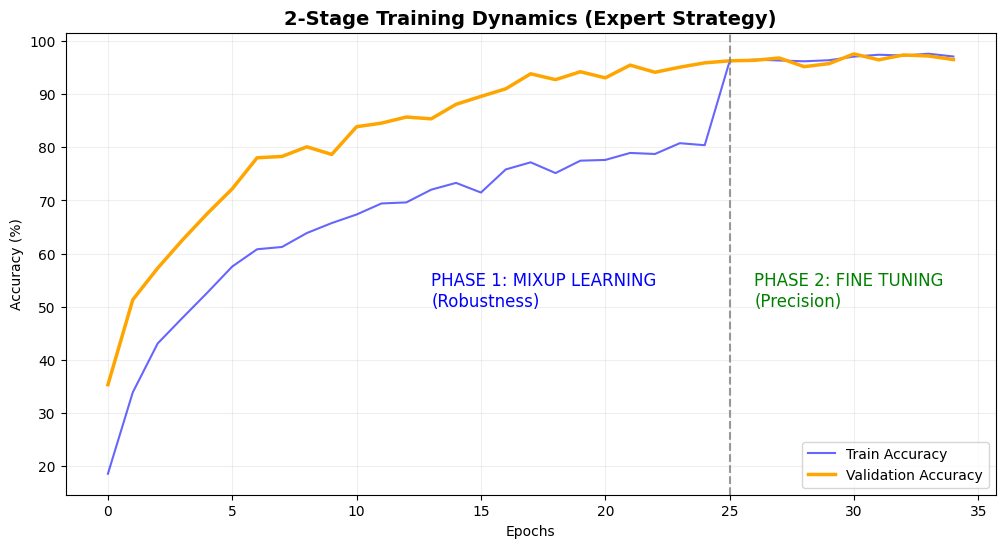

/tmp/ipython-input-4045741690.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='F1-Score', y='Class', data=df_perf, palette=colors)


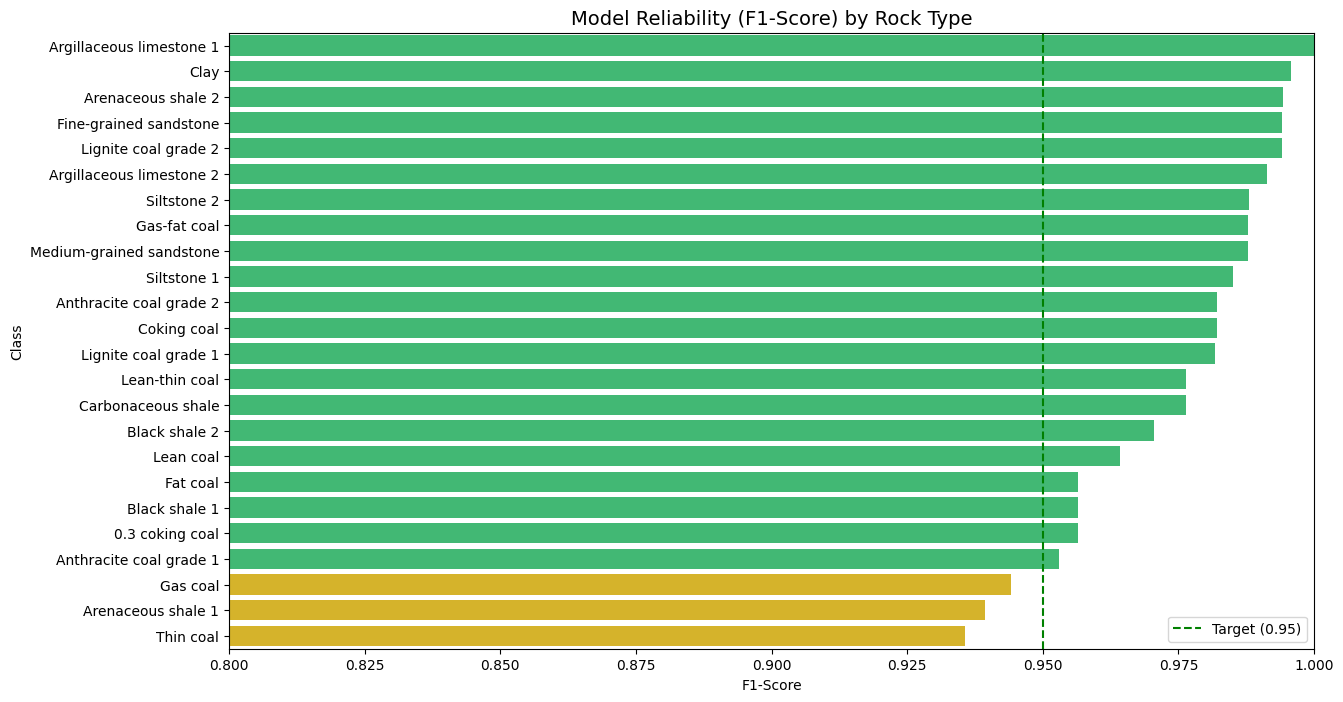

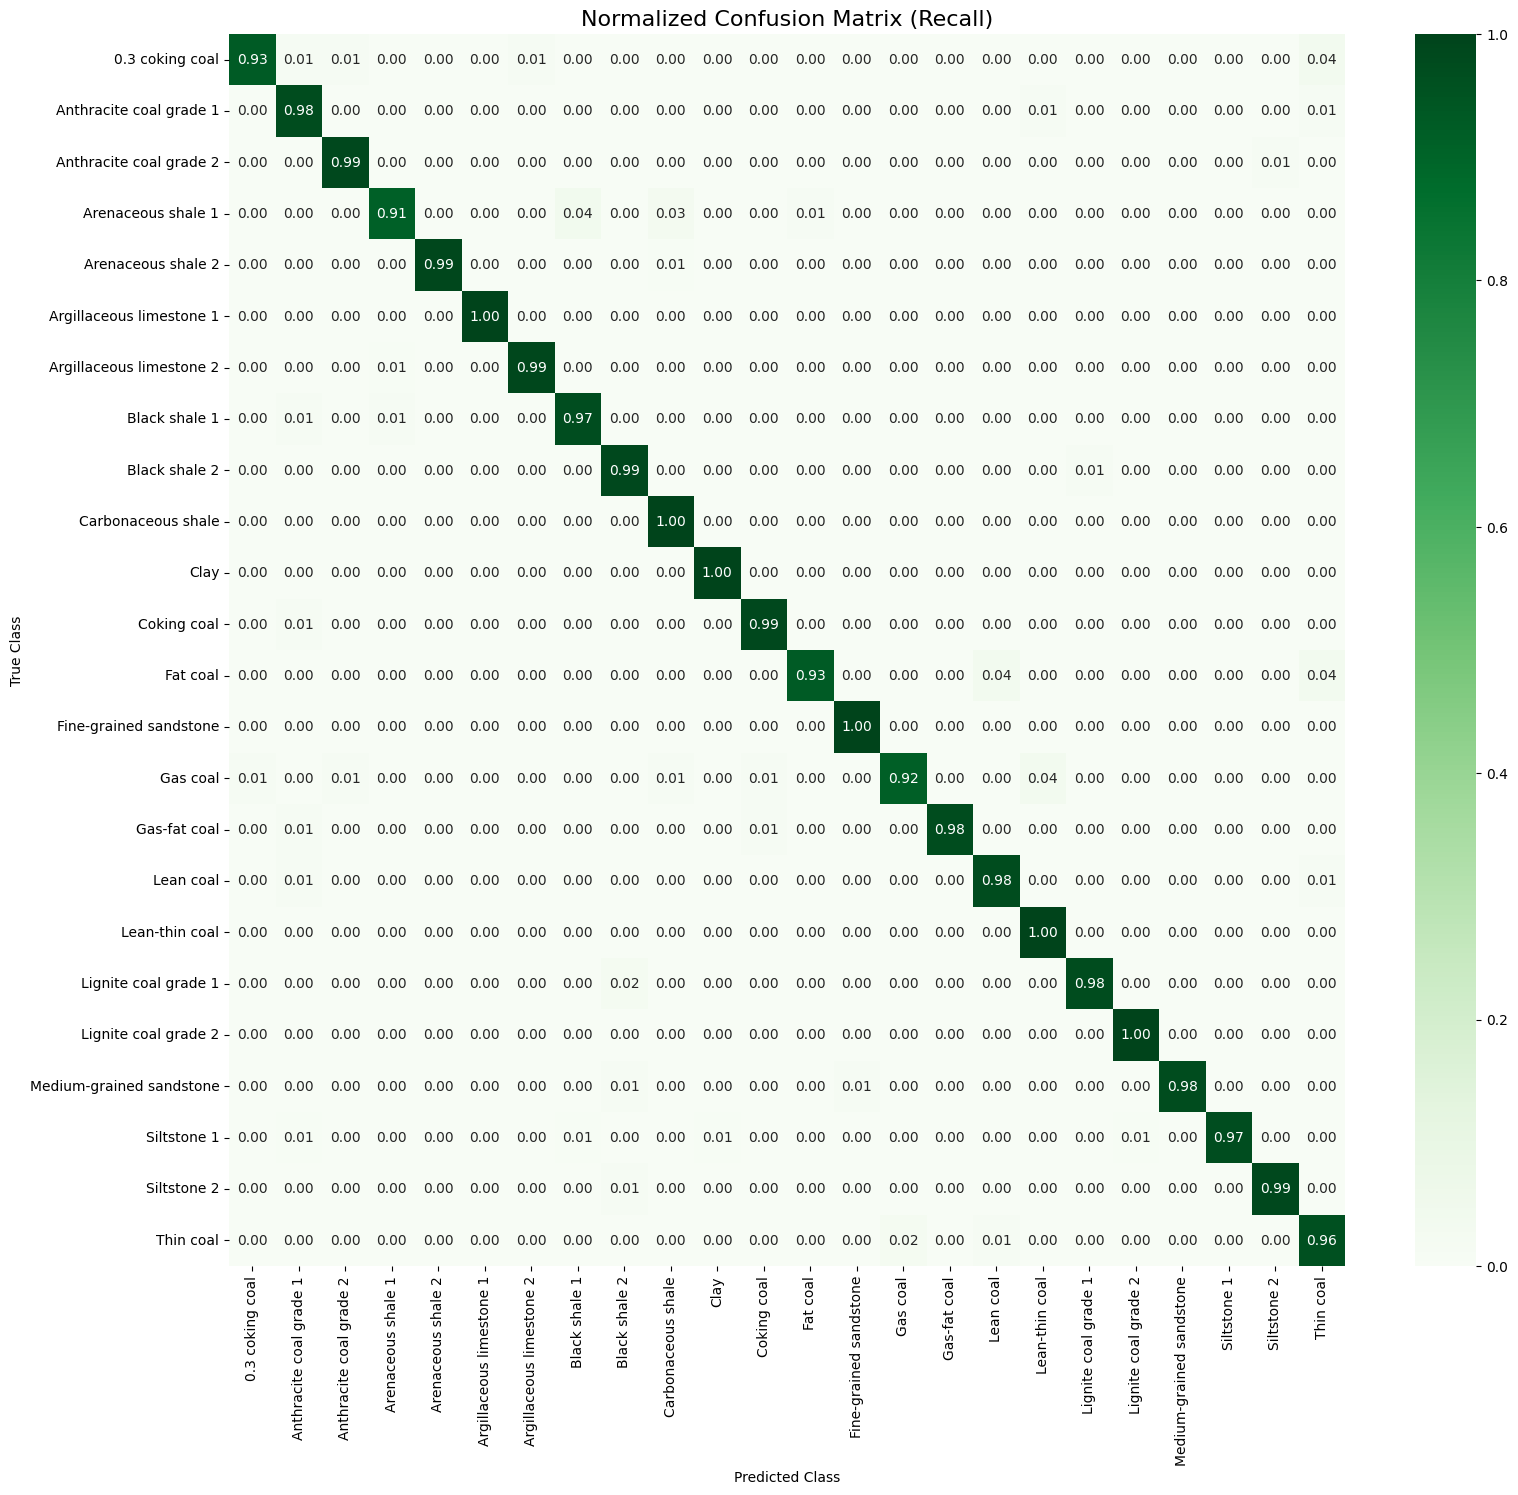

In [ ]:
# ADVANCED PRESENTATION METRICS
from sklearn.metrics import precision_recall_fscore_support
import matplotlib.patches as mpatches

# Load Resources
model.load_state_dict(torch.load(MODEL_SAVE_PATH))
model.eval()
with open(HISTORY_PATH, 'rb') as f: h = pickle.load(f)

# THE 2-STAGE LEARNING CURVE
plt.figure(figsize=(12, 6))
plt.plot(h['train_acc'], label='Train Accuracy', color='blue', alpha=0.6)
plt.plot(h['val_acc'], label='Validation Accuracy', color='orange', linewidth=2.5)

# Add Phase Marker
plt.axvline(x=MIXUP_EPOCHS, color='grey', linestyle='--', alpha=0.8)
plt.text(MIXUP_EPOCHS-12, 50, "PHASE 1: MIXUP LEARNING\n(Robustness)", fontsize=12, color='blue')
plt.text(MIXUP_EPOCHS+1, 50, "PHASE 2: FINE TUNING\n(Precision)", fontsize=12, color='green')

plt.title("2-Stage Training Dynamics (Expert Strategy)", fontsize=14, fontweight='bold')
plt.ylabel("Accuracy (%)"); plt.xlabel("Epochs")
plt.legend(loc='lower right'); plt.grid(True, alpha=0.2)
plt.show()

# F1-SCORE
y_true, y_pred = [], []
with torch.no_grad():
    for x, y in test_dl:
        x = x.cuda()
        out = model(x)
        _, p = torch.max(out, 1)
        y_true.extend(y.cpu().numpy())
        y_pred.extend(p.cpu().numpy())

# Calculate Metrics
precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average=None)
df_perf = pd.DataFrame({'Class': le.classes_, 'F1-Score': f1})
df_perf = df_perf.sort_values('F1-Score', ascending=False)

plt.figure(figsize=(14, 8))
# Color logic: Green for >95%, Yellow for >90%, Red for <90%
colors = ['#2ecc71' if x >= 0.95 else '#f1c40f' if x >= 0.90 else '#e74c3c' for x in df_perf['F1-Score']]
sns.barplot(x='F1-Score', y='Class', data=df_perf, palette=colors)
plt.axvline(0.95, color='green', linestyle='--', label='Target (0.95)')
plt.title("Model Reliability (F1-Score) by Rock Type", fontsize=14)
plt.xlim(0.8, 1.0)
plt.legend()
plt.show()

# CONFUSION MATRIX
plt.figure(figsize=(18, 16))
cm = confusion_matrix(y_true, y_pred, normalize='true')
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Greens', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Normalized Confusion Matrix (Recall)", fontsize=16)
plt.ylabel("True Class"); plt.xlabel("Predicted Class")
plt.show()

In [ ]:
# SAVE METRICS TO CSV
import pandas as pd

# Load the history dictionary
with open(f"{PROJECT_ROOT}/models/training_history_expert.pkl", 'rb') as f:
    history = pickle.load(f)

# Convert to DataFrame
df_metrics = pd.DataFrame(history)
df_metrics.index.name = 'Epoch'

# Save to Drive
csv_path = f"{PROJECT_ROOT}/results/final_metrics.csv"
df_metrics.to_csv(csv_path)

print(f"Metrics saved to: {csv_path}")
print(df_metrics.head(35))